In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import data_analytics_lib as dal
import random

# Exercise 1 - Write a python function that reads in the Seattle housing data and puts it into an appropriate data structure(s). Note, there some entries in the database where price, sqft_living and sqft_lot are equal to 0. There may be explanations for these entries or they might be input errors. Exclude these records from your analyses.

In [17]:
def read_data(file_path):

    data_by_statezip = {}

    with open(file_path, "r") as file:
        next(file)  # Skip the header line
        
        for line in file:

            lines = line.strip().split(",")

            zip_code = lines[-2]
            
            if zip_code not in data_by_statezip:
                data_by_statezip[zip_code] = {
                    'date': [],
                    'price': [],
                    'bedrooms': [],
                    'bathrooms': [],
                    'sqft_living': [],
                    'sqft_lot': [],
                    'floors': [],
                    'waterfront': [],
                    'view': [],
                    'condition': [],
                    'sqft_above': [],
                    'sqft_basement': [],
                    'yr_built': [],
                    'yr_renovated': [],
                    'street': [],
                    'city': [],
                    'country': []
                }
            # if lines[1] == '0' or lines[4] == '0' or lines[5] == '0':
            #     continue
            
            # else:
            data_by_statezip[zip_code]['date'].append(lines[0])
            data_by_statezip[zip_code]['price'].append(float(lines[1]))
            data_by_statezip[zip_code]['bedrooms'].append(float(lines[2]))
            data_by_statezip[zip_code]['bathrooms'].append(float(lines[3]))
            data_by_statezip[zip_code]['sqft_living'].append(float(lines[4]))
            data_by_statezip[zip_code]['sqft_lot'].append(float(lines[5]))
            data_by_statezip[zip_code]['floors'].append(float(lines[6]))
            data_by_statezip[zip_code]['waterfront'].append(float(lines[7]))
            data_by_statezip[zip_code]['view'].append(float(lines[8]))
            data_by_statezip[zip_code]['condition'].append(float(lines[9]))
            data_by_statezip[zip_code]['sqft_above'].append(float(lines[10]))
            data_by_statezip[zip_code]['sqft_basement'].append(float(lines[11]))
            data_by_statezip[zip_code]['yr_built'].append(float(lines[12]))
            data_by_statezip[zip_code]['yr_renovated'].append(float(lines[13]))
            data_by_statezip[zip_code]['street'].append(lines[14])
            data_by_statezip[zip_code]['city'].append(lines[15])
            data_by_statezip[zip_code]['country'].append(lines[17])
            
            

    return data_by_statezip

state_zip_data = read_data("/Users/244213/Desktop/DataAnalytics/Stats/housing_data.csv")

print(state_zip_data)

{'WA 98133': {'date': ['5/2/2014 0:00', '5/5/2014 0:00', '5/5/2014 0:00', '5/5/2014 0:00', '5/5/2014 0:00', '5/6/2014 0:00', '5/6/2014 0:00', '5/7/2014 0:00', '5/7/2014 0:00', '5/7/2014 0:00', '5/9/2014 0:00', '5/13/2014 0:00', '5/13/2014 0:00', '5/13/2014 0:00', '5/14/2014 0:00', '5/14/2014 0:00', '5/14/2014 0:00', '5/14/2014 0:00', '5/14/2014 0:00', '5/15/2014 0:00', '5/15/2014 0:00', '5/15/2014 0:00', '5/15/2014 0:00', '5/15/2014 0:00', '5/16/2014 0:00', '5/19/2014 0:00', '5/19/2014 0:00', '5/20/2014 0:00', '5/20/2014 0:00', '5/20/2014 0:00', '5/20/2014 0:00', '5/21/2014 0:00', '5/21/2014 0:00', '5/23/2014 0:00', '5/25/2014 0:00', '5/27/2014 0:00', '5/27/2014 0:00', '5/28/2014 0:00', '5/29/2014 0:00', '5/29/2014 0:00', '5/29/2014 0:00', '5/29/2014 0:00', '6/2/2014 0:00', '6/3/2014 0:00', '6/4/2014 0:00', '6/4/2014 0:00', '6/5/2014 0:00', '6/9/2014 0:00', '6/9/2014 0:00', '6/10/2014 0:00', '6/10/2014 0:00', '6/11/2014 0:00', '6/11/2014 0:00', '6/11/2014 0:00', '6/11/2014 0:00', '6/11

# Exercise 2

# A. Investigate the correlation between the size of the house (sqft_living) and price and the lot size (sqft_lot) and price by computing the correlation coefficient. Note, there some entries in the database where price is equal to 0. When doing computations that involve the price exclude these entries from your computation.

In [18]:
price_list = []
sqft_living_list = []
sqft_lot_list = []
condition_list = []



for zip in state_zip_data.keys():
    for i in range(len(state_zip_data[zip]['price'])):
        if (state_zip_data[zip]['price'][i] > 0 and state_zip_data[zip]['price'][i] <= 5000000) and (state_zip_data[zip]['sqft_lot'][i] > 0 and state_zip_data[zip]['sqft_lot'][i] <= 200000):
            price_list.append(state_zip_data[zip]['price'][i])
            sqft_living_list.append(state_zip_data[zip]['sqft_living'][i])
            sqft_lot_list.append(state_zip_data[zip]['sqft_lot'][i])
            condition_list.append(state_zip_data[zip]['condition'][i])


print(len(price_list))
correlation_price_sqft_lot = dal.find_data_correlation(price_list, sqft_lot_list)
correlation_price_sqft_living = dal.find_data_correlation(price_list, sqft_living_list)


print(f'Corelation Coefficient of Price to Square Foot Living: {correlation_price_sqft_living}')
print(f'Corelation Coefficient of Price to Square Foot Lot: {correlation_price_sqft_lot}')

4501
Corelation Coefficient of Price to Square Foot Living: 0.6956022607356459
Corelation Coefficient of Price to Square Foot Lot: 0.11539180549049008


## B. Develop a linear regression model for cost for each of the two independent variables sqft_living and sqft_lot with price. Plot the graphs for each model. On the plots show the raw data , the regression line and the two sigma error bars. Which one is a better predictor?

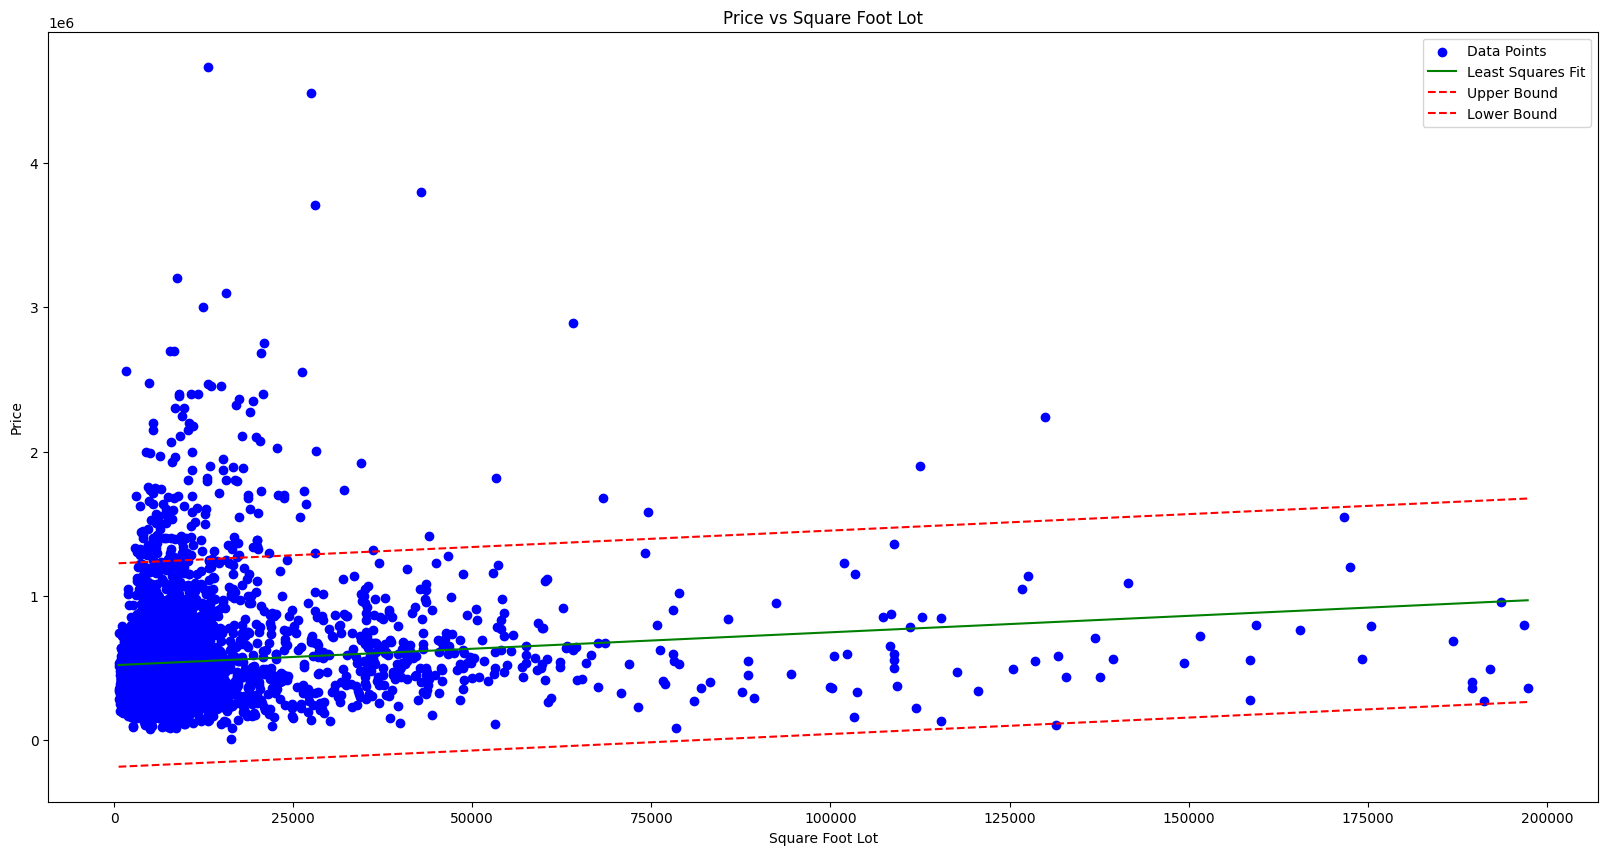

In [19]:
plt.figure(figsize=(20, 10))
dal.graph__least_squares(sqft_lot_list, price_list)
dal.graphing_error_bars(sqft_lot_list, price_list, fit = 1, xlabel='Square Foot Lot', ylabel='Price', title='Price vs Square Foot Lot')

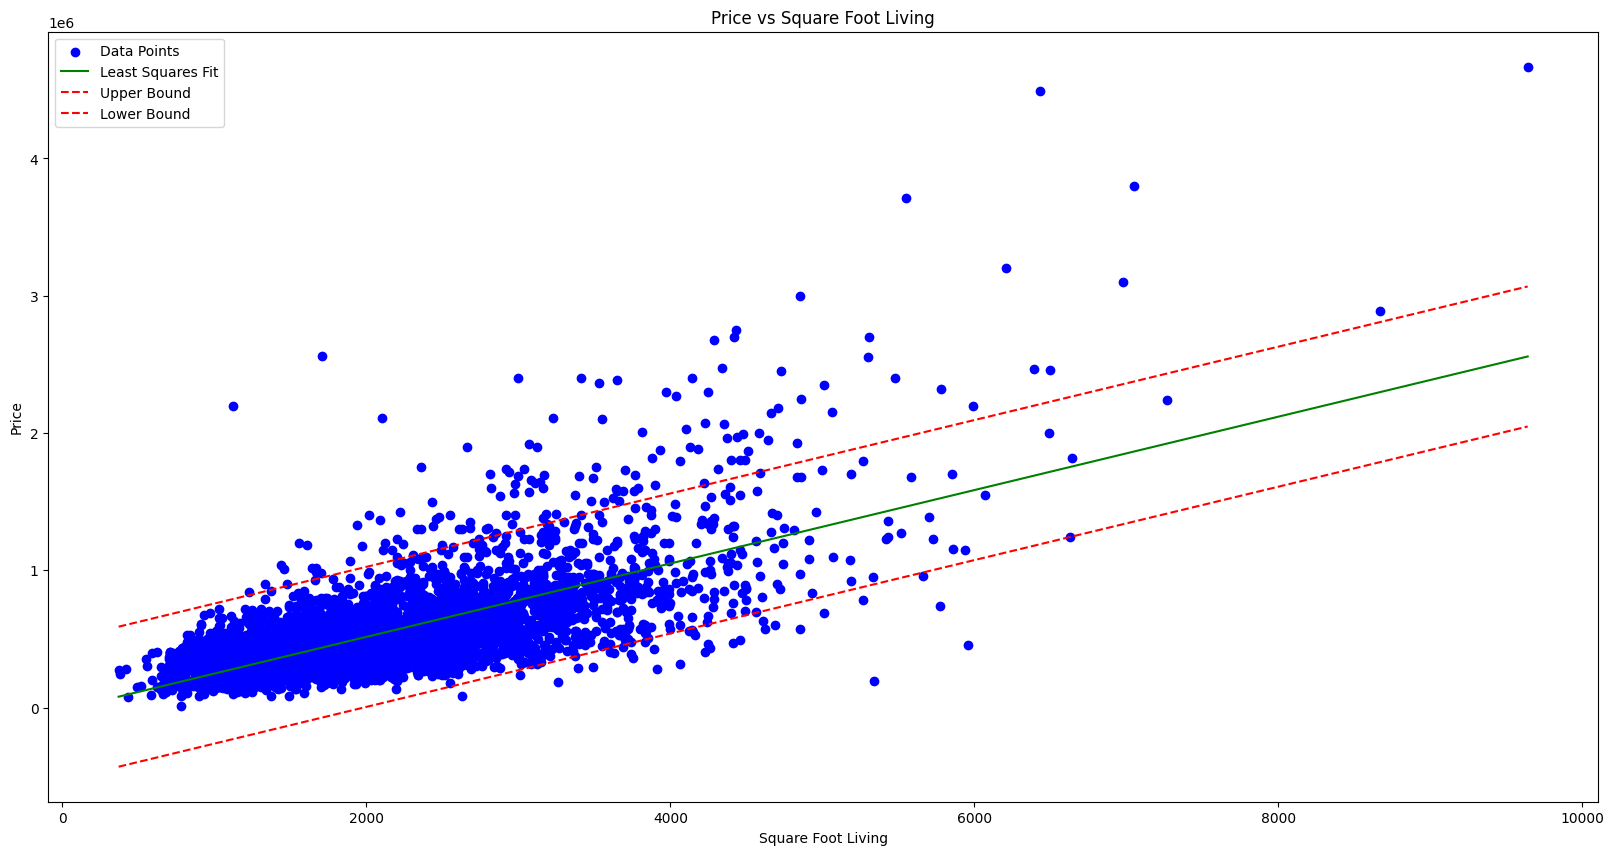

In [20]:
plt.figure(figsize=(20, 10))
dal.graph__least_squares(sqft_living_list, price_list)
dal.graphing_error_bars(sqft_living_list, price_list, fit = 1, xlabel='Square Foot Living', ylabel='Price', title='Price vs Square Foot Living')

Square Foot Living is a much better predictor as the fit of the line is much better, and the data stays in the error bars much more.

## C. Choose one idea from those discussed in class other than those in parts a and b. Provide your analysis and the reasons why you choose the analytical techniques you did.

In [21]:
# Sorting the conditions with prices. Each condition will have a list of prices associated with it. I'm doing this because the scale between prices and conditions vary significantly, both with number of varying data available and the price ranges themselves. Then I'm going to get the regular statistics of each to get a read on how condition affects things like average price.

matched_conditions_with_price = {condition: [] for condition in condition_list}

print(matched_conditions_with_price)
for i in range(len(condition_list)):
    condition = condition_list[i]
    price = price_list[i]
    matched_conditions_with_price[condition].append(price)

condition_stats1 = dal.main_stats(matched_conditions_with_price[1.0])
condition_stats2 = dal.main_stats(matched_conditions_with_price[2.0])
condition_stats3 = dal.main_stats(matched_conditions_with_price[3.0])
condition_stats4 = dal.main_stats(matched_conditions_with_price[4.0])
condition_stats5 = dal.main_stats(matched_conditions_with_price[5.0])

print(f'Stats for a condition of 1: {condition_stats1}')
print(f'Stats for a condition of 2: {condition_stats2}')
print(f'Stats for a condition of 3: {condition_stats3}')
print(f'Stats for a condition of 4: {condition_stats4}')
print(f'Stats for a condition of 5: {condition_stats5}')


{3.0: [], 4.0: [], 5.0: [], 2.0: [], 1.0: []}
Stats for a condition of 1: {'mean': 306633.33, 'median': 310000.0, 'variance': 29036805555.56, 'std_dev': 170401.89, 'max': 550000.0, 'min': 7800.0}
Stats for a condition of 2: {'mean': 334998.67, 'median': 250000.0, 'variance': 184107949618.22, 'std_dev': 429078.02, 'max': 2555000.0, 'min': 80000.0}
Stats for a condition of 3: {'mean': 545981.94, 'median': 465000.0, 'variance': 118531665147.47, 'std_dev': 344284.28, 'max': 4668000.0, 'min': 83000.0}
Stats for a condition of 4: {'mean': 517570.6, 'median': 440000.0, 'variance': 117568427857.43, 'std_dev': 342882.53, 'max': 3800000.0, 'min': 83300.0}
Stats for a condition of 5: {'mean': 653657.52, 'median': 559326.92, 'variance': 179819645976.28, 'std_dev': 424051.47, 'max': 3200000.0, 'min': 83300.0}


# Project Code

## Getting the Statistics for each Zipcode

In [22]:
# Cleaning the state_zip_data

cleaned_state_zip_data = {}

for zip in state_zip_data.keys():
    if zip not in cleaned_state_zip_data:
        cleaned_state_zip_data[zip] = {
                'price': [],
                'bathrooms': [],
                'bedrooms': [],
                'sqft_living': [],
                'sqft_lot': [],
                'yr_built': []
            }
            
        for i in range(len(state_zip_data[zip]['price'])):
            
            if (state_zip_data[zip]['price'][i] > 0 and state_zip_data[zip]['price'][i] <= 5000000) and (state_zip_data[zip]['sqft_lot'][i] > 0 and state_zip_data[zip]['sqft_lot'][i] <= 200000):

                cleaned_state_zip_data[zip]['price'].append(state_zip_data[zip]['price'][i])
                cleaned_state_zip_data[zip]['bathrooms'].append(state_zip_data[zip]['bathrooms'][i])
                cleaned_state_zip_data[zip]['bedrooms'].append(state_zip_data[zip]['bedrooms'][i])
                cleaned_state_zip_data[zip]['sqft_living'].append(state_zip_data[zip]['sqft_living'][i])
                cleaned_state_zip_data[zip]['sqft_lot'].append(state_zip_data[zip]['sqft_lot'][i])
                cleaned_state_zip_data[zip]['yr_built'].append(state_zip_data[zip]['yr_built'][i])




# Getting statistics for the specific zip code

def zip_code_stats(state_zip_data, zipcode):
    specific_zip = zipcode
    zip_code_stats = {}

    for zip_code in cleaned_state_zip_data.keys():

        if zip_code == f'WA {specific_zip}':
            price_stats = dal.main_stats(cleaned_state_zip_data[zip_code]['price'])
            bathroom_stats = dal.main_stats(cleaned_state_zip_data[zip_code]['bathrooms'])
            bedroom_stats = dal.main_stats(cleaned_state_zip_data[zip_code]['bedrooms'])
            sqft_living_stats = dal.main_stats(cleaned_state_zip_data[zip_code]['sqft_living'])
            sqft_lot_stats = dal.main_stats(cleaned_state_zip_data[zip_code]['sqft_lot'])
            year_stats = dal.main_stats(cleaned_state_zip_data[zip_code]['yr_built'])

            zip_code_stats = {
                'Price': {'min': price_stats['min'], 'max': price_stats['max'], 'mean': price_stats['mean'], 'median': price_stats['median'], 'stdev': price_stats['std_dev']},
                'bathrooms': {'min': bathroom_stats['min'], 'max': bathroom_stats['max'], 'mean': bathroom_stats['mean'], 'median': bathroom_stats['median'], 'stdev': bathroom_stats['std_dev']},
                'bedrooms': {'min': bedroom_stats['min'], 'max': bedroom_stats['max'], 'mean': bedroom_stats['mean'], 'median': bedroom_stats['median'], 'stdev': bedroom_stats['std_dev']},
                'SqFt_Living': {'min': sqft_living_stats['min'], 'max': sqft_living_stats['max'], 'mean': sqft_living_stats['mean'], 'median': sqft_living_stats['median'], 'stdev': sqft_living_stats['std_dev']},
                'SqFt_Lot': {'min': sqft_lot_stats['min'], 'max': sqft_lot_stats['max'], 'mean': sqft_lot_stats['mean'], 'median': sqft_lot_stats['median'], 'stdev': sqft_lot_stats['std_dev']},
                'Year': {'min': year_stats['min'], 'max': year_stats['max'], 'mean': year_stats['mean'], 'median': year_stats['median'], 'stdev': year_stats['std_dev']}
            }

    return zip_code_stats


zip_code_statistics_98042 = zip_code_stats(cleaned_state_zip_data, '98042')
zip_code_statistics_98006 = zip_code_stats(cleaned_state_zip_data, '98006')
zip_code_statistics_98103 = zip_code_stats(cleaned_state_zip_data, '98103')

zip_df_98042 = pd.DataFrame(zip_code_statistics_98042)
zip_df_98006 = pd.DataFrame(zip_code_statistics_98006)
zip_df_98103 = pd.DataFrame(zip_code_statistics_98103)

zip_df_98042


,Price,bathrooms,bedrooms,SqFt_Living,SqFt_Lot,Year
min,83300.00,1.00,1.00,650.00,3814.00,1945.00
max,2199900.00,3.50,5.00,3800.00,108366.00,2012.00
mean,326779.56,2.14,3.36,2009.74,18284.42,1984.77
median,290500.00,2.25,3.00,1915.00,9600.00,1984.00
stdev,217298.61,0.56,0.67,674.45,20257.81,14.28


## Histograms for the Zipcodes

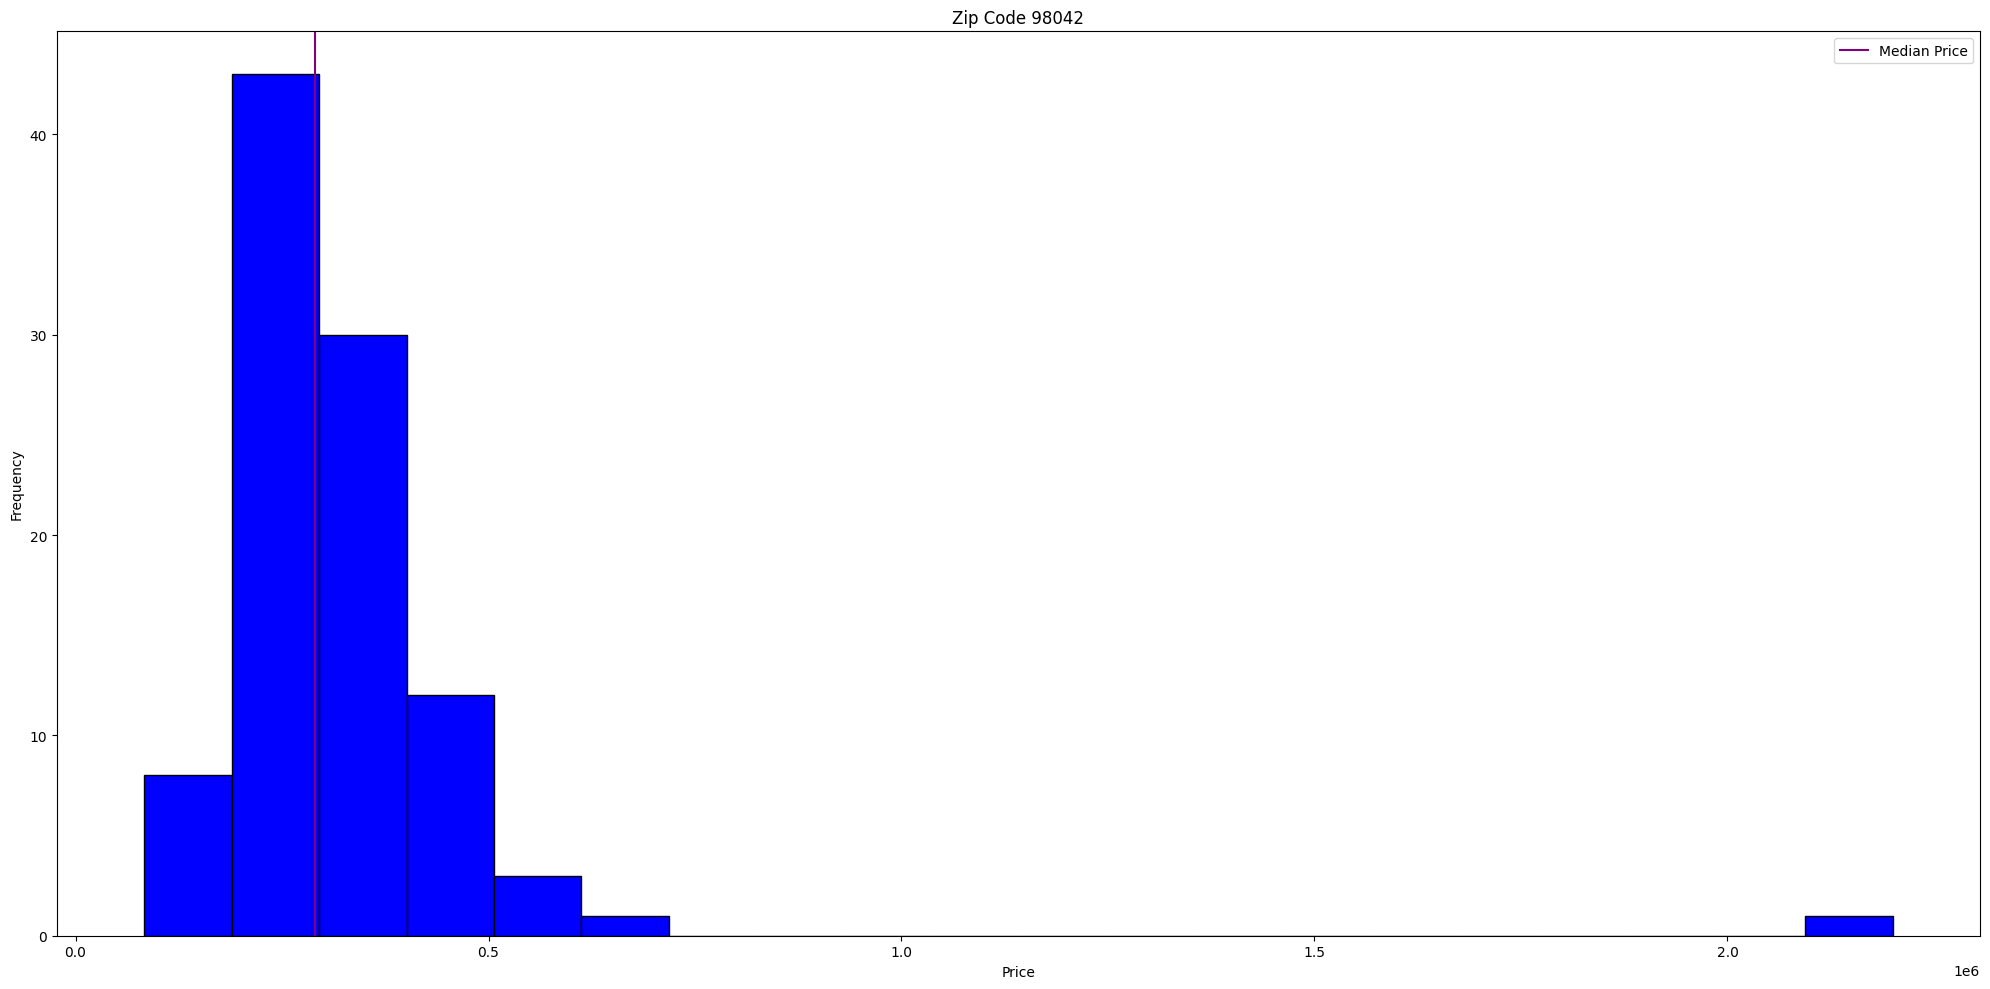

In [23]:
plt.figure(figsize=(20, 10))

dal.histogram(cleaned_state_zip_data['WA 98042']['price'], color = 'blue', xaxis_label='Price', yaxis_label='Frequency', title='Price Distribution for Zip Code 98042')
plt.axvline(x=dal.main_stats(cleaned_state_zip_data['WA 98042']['price'])['median'], color='purple', linestyle='-', label='Median Price')
plt.title('Zip Code 98042')

plt.legend()
plt.show()

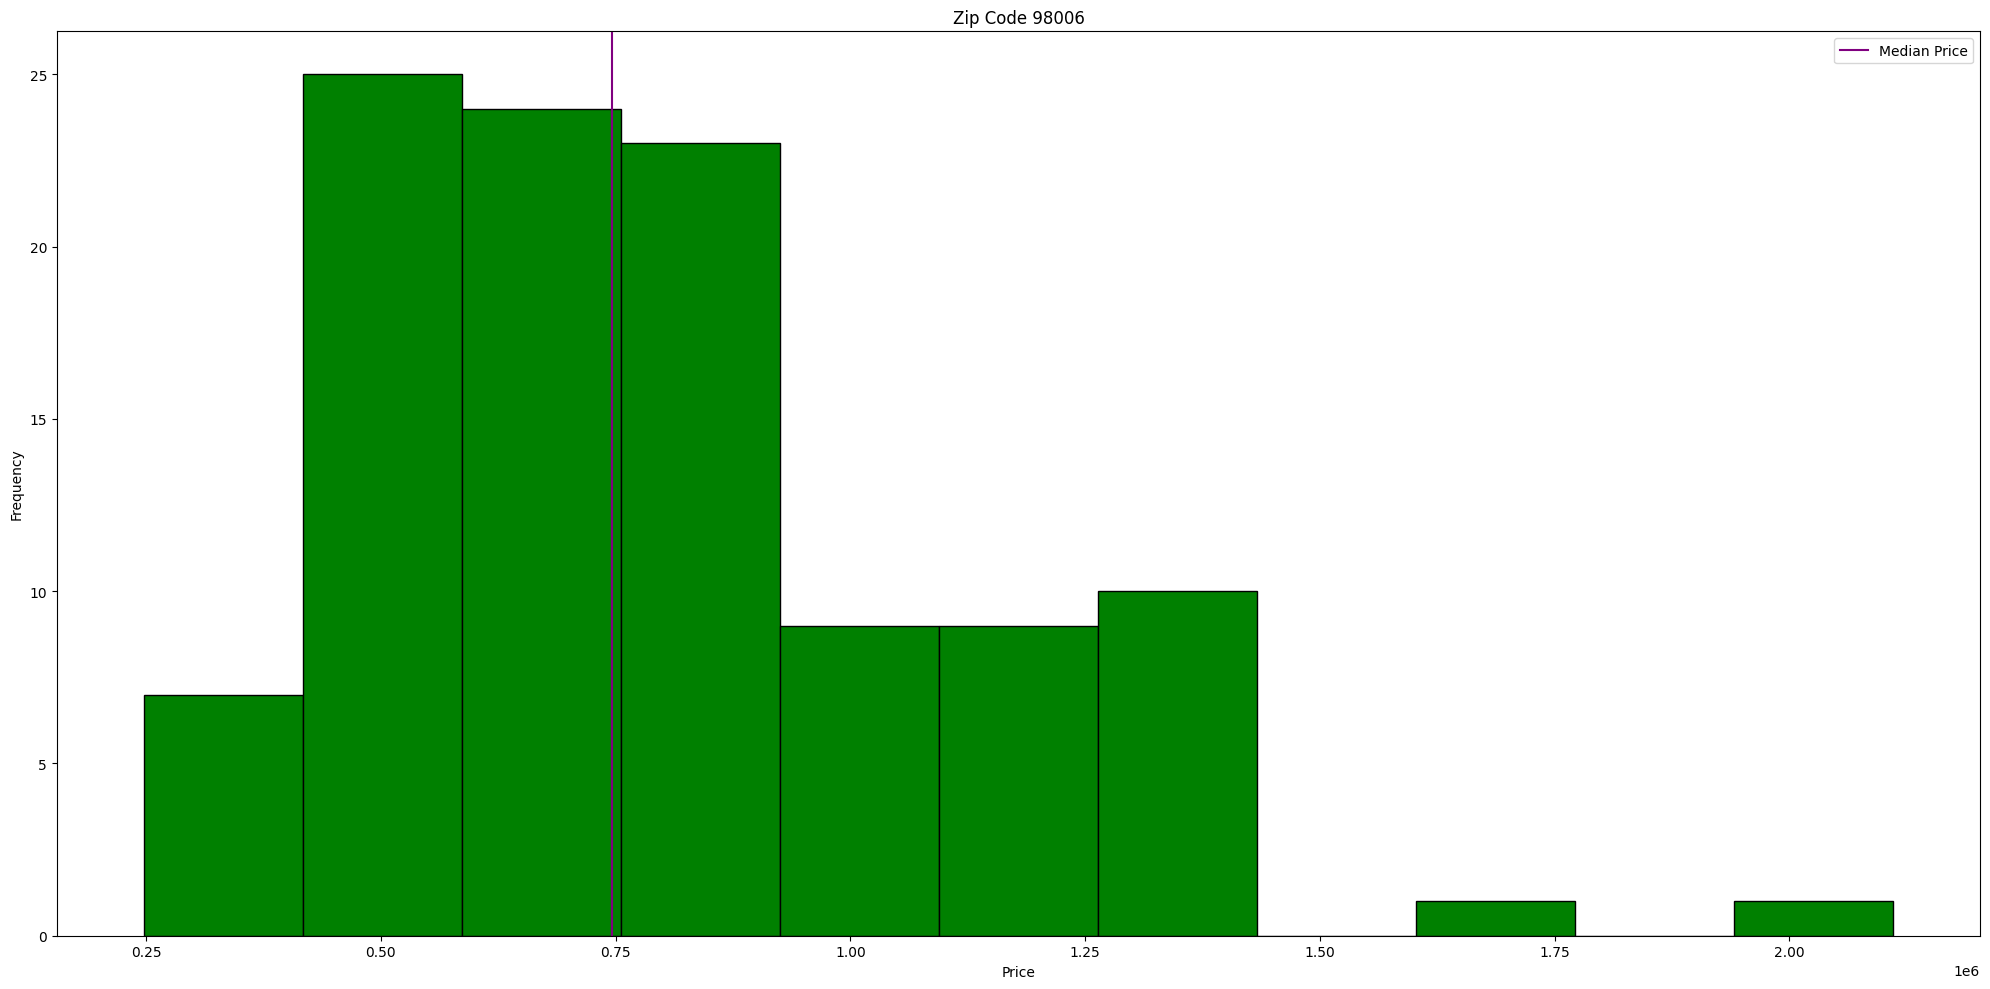

In [24]:
plt.figure(figsize=(20, 10))

dal.histogram(cleaned_state_zip_data['WA 98006']['price'], color = 'green', xaxis_label='Price', yaxis_label='Frequency', title='Price Distribution for Zip Code 98006')
plt.axvline(x=dal.main_stats(cleaned_state_zip_data['WA 98006']['price'])['median'], color='purple', linestyle='-', label='Median Price')
plt.title('Zip Code 98006')

plt.legend()
plt.show()

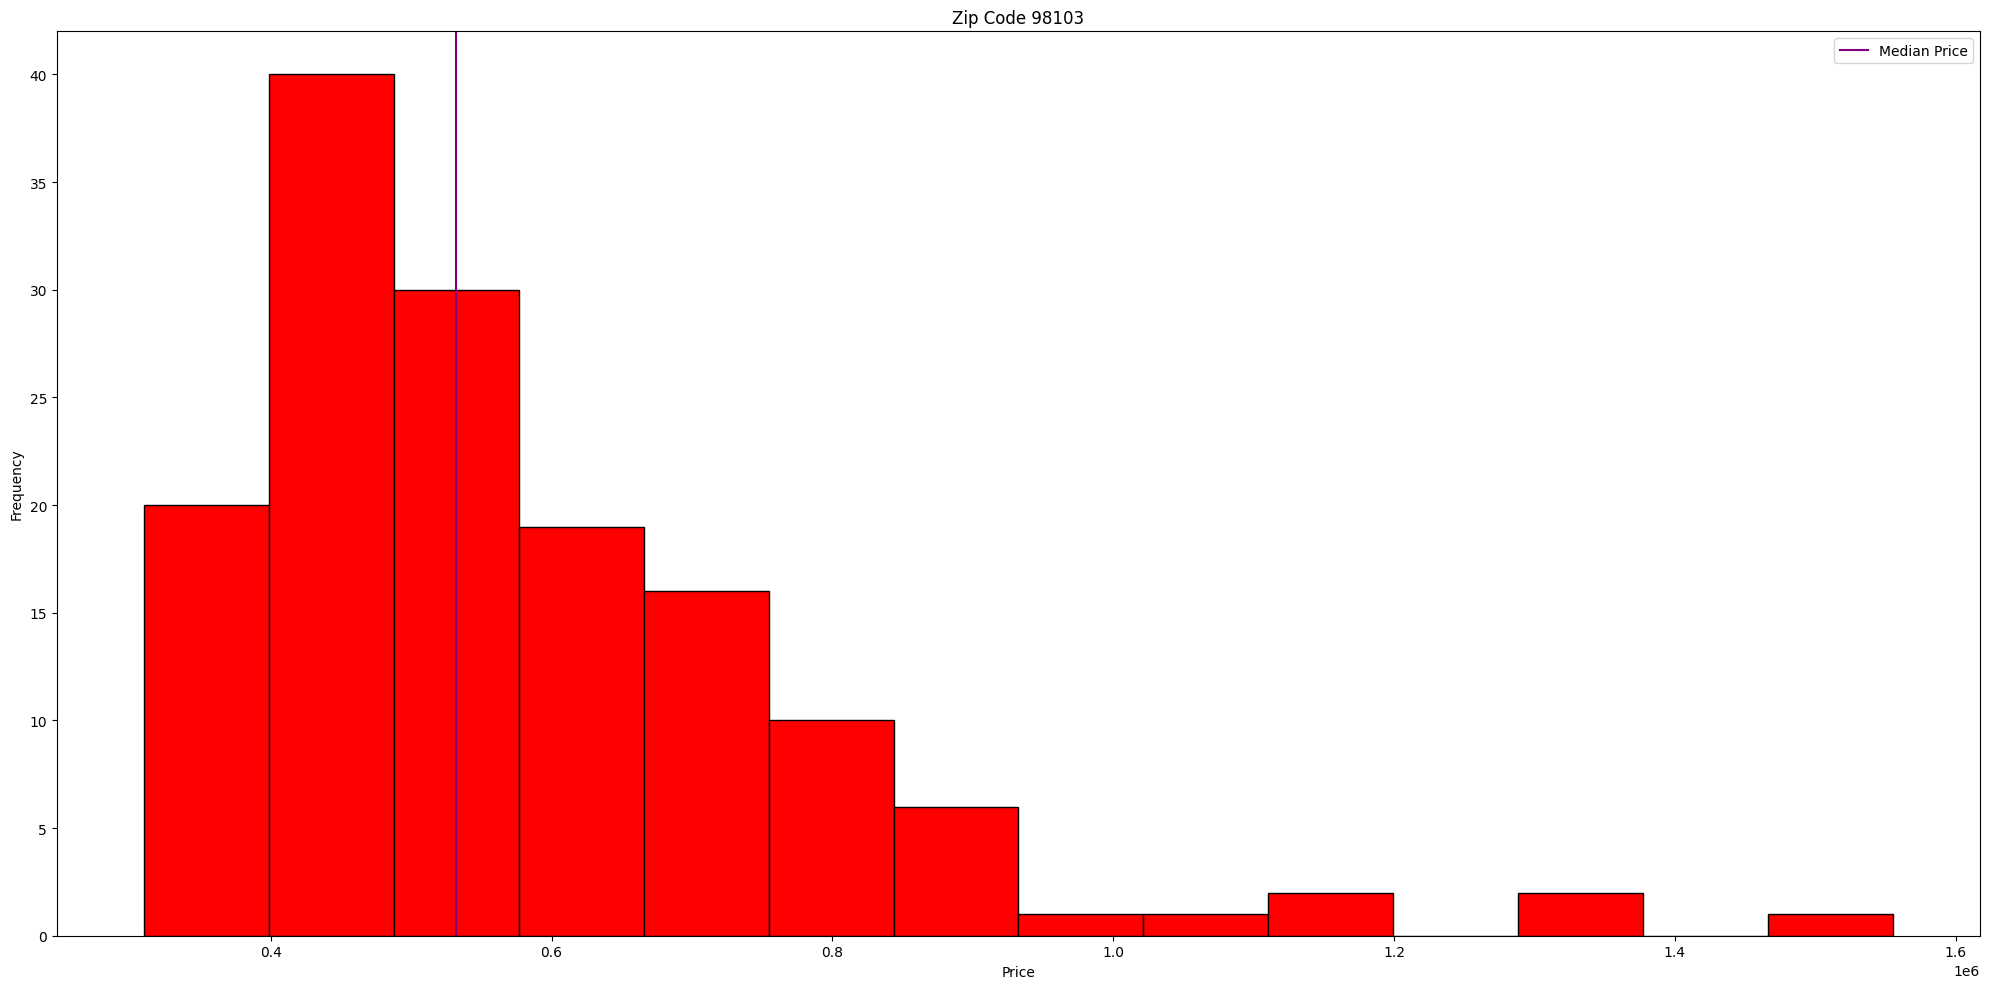

In [25]:
plt.figure(figsize=(20, 10))

dal.histogram(cleaned_state_zip_data['WA 98103']['price'], color = 'red', xaxis_label='Price', yaxis_label='Frequency', title='Price Distribution for Zip Code 98103')
plt.axvline(x=dal.main_stats(cleaned_state_zip_data['WA 98103']['price'])['median'], color='purple', linestyle='-', label='Median Price')
plt.title('Zip Code 98103')

plt.legend()    
plt.show()

## Least Squares Fit of the Price as a Function of Sqft_living along with CC

np.float64(0.2705472227830536)

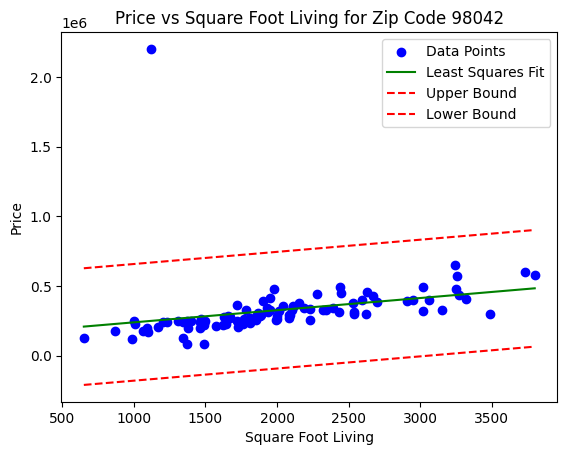

In [26]:
plt.Figure(figsize=(20, 10))
dal.graph__least_squares(cleaned_state_zip_data['WA 98042']['sqft_living'], cleaned_state_zip_data['WA 98042']['price'])
dal.graphing_error_bars(cleaned_state_zip_data['WA 98042']['sqft_living'], cleaned_state_zip_data['WA 98042']['price'], fit = 1, xlabel='Square Foot Living', ylabel='Price', title='Price vs Square Foot Living for Zip Code 98042')
dal.find_data_correlation(cleaned_state_zip_data['WA 98042']['sqft_living'], cleaned_state_zip_data['WA 98042']['price'])

np.float64(0.7528578057950285)

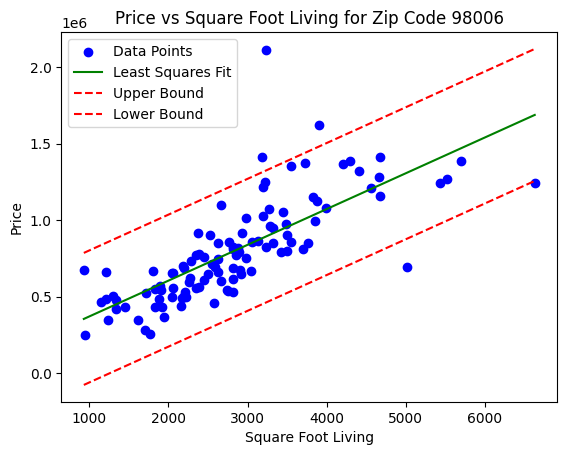

In [27]:
plt.Figure(figsize=(20, 10))
dal.graph__least_squares(cleaned_state_zip_data['WA 98006']['sqft_living'], cleaned_state_zip_data['WA 98006']['price'])
dal.graphing_error_bars(cleaned_state_zip_data['WA 98006']['sqft_living'], cleaned_state_zip_data['WA 98006']['price'], fit = 1, xlabel='Square Foot Living', ylabel='Price', title='Price vs Square Foot Living for Zip Code 98006')
dal.find_data_correlation(cleaned_state_zip_data['WA 98006']['sqft_living'], cleaned_state_zip_data['WA 98006']['price'])

np.float64(0.7274204232443069)

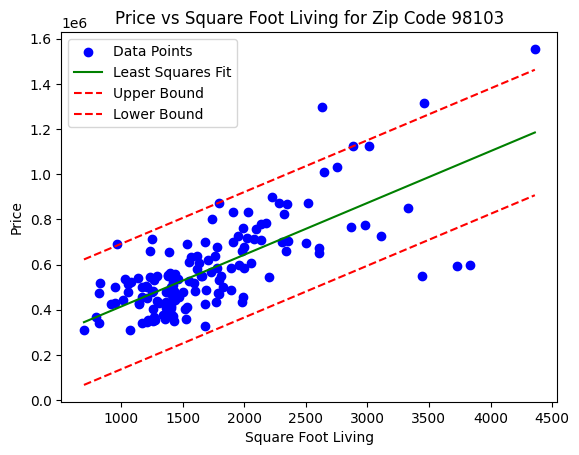

In [28]:
plt.Figure(figsize=(20, 10))
dal.graph__least_squares(cleaned_state_zip_data['WA 98103']['sqft_living'], cleaned_state_zip_data['WA 98103']['price'])
dal.graphing_error_bars(cleaned_state_zip_data['WA 98103']['sqft_living'], cleaned_state_zip_data['WA 98103']['price'], fit = 1, xlabel='Square Foot Living', ylabel='Price', title='Price vs Square Foot Living for Zip Code 98103')
dal.find_data_correlation(cleaned_state_zip_data['WA 98103']['sqft_living'], cleaned_state_zip_data['WA 98103']['price'])

# Project Code 4A: A Real Estate

In [ ]:
def get_user_input(data):
    state_zip_data = data
    requested_data = {}   
    matching_listings = []
    matching_listing_data = {
        
    }
    top_5_listings = {}
    
    ### Temp Hard Code
    zip = "98006"
    bed_min = 1
    bed_max = 3
    bath_min = 1
    bath_max = 2
    sqft_min = 500
    sqft_max = 2000
    price_min = 1
    price_max = 800000

    ### User inputs
    
    # zip = input("Please enter your ZIP code: ")
    # bed_min = input("Please enter the minimum number of bedrooms: ")
    # bed_max = input("Please enter the maximum number of bedrooms: ")
    # bath_min = input("Please enter the minimum number of bathrooms: ")
    # bath_max = input("Please enter the maximum number of bathrooms: ")
    # sqft_min = input("Please enter the minimum square footage: ")
    # sqft_max = input("Please enter the maximum square footage: ")
    # price_min = input("Please enter the minimum desired price: ")
    # price_max = input("Please enter the maximum desired price: ")

    requested_data["zip"] = f'WA {zip}'
    requested_data["bedrooms"] = [bed_min, bed_max]
    requested_data["bathrooms"] = [bath_min, bath_max]
    requested_data["sqft"] = [sqft_min, sqft_max]
    requested_data["price"] = [price_min, price_max]

    ### Finding all listings that satisfy the requirements
    for zipcode in state_zip_data:
        for i in range(len(state_zip_data[zipcode]['price'])):
            if (zipcode == requested_data['zip'] and
                state_zip_data[zipcode]["bedrooms"][i] >= requested_data["bedrooms"][0] and
                state_zip_data[zipcode]["bedrooms"][i] <= requested_data["bedrooms"][1] and
                state_zip_data[zipcode]["bathrooms"][i] >= requested_data["bathrooms"][0] and
                state_zip_data[zipcode]["bathrooms"][i] <= requested_data["bathrooms"][1] and
                state_zip_data[zipcode]["sqft_living"][i] >= requested_data["sqft"][0] and
                state_zip_data[zipcode]["sqft_living"][i] <= requested_data["sqft"][1] and
                state_zip_data[zipcode]["price"][i] >= requested_data["price"][0] and
                state_zip_data[zipcode]["price"][i] <= requested_data["price"][1]):

                    matching_listings.append(i)

                    if state_zip_data[zipcode]["street"][i] not in matching_listing_data:
                        matching_listing_data[state_zip_data[zipcode]["street"][i]] = {
                            "bedrooms": state_zip_data[zipcode]["bedrooms"][i],
                            "bathrooms": state_zip_data[zipcode]["bathrooms"][i],
                            "sqft_living": state_zip_data[zipcode]["sqft_living"][i],
                            "price": state_zip_data[zipcode]["price"][i]
                        }

    print(matching_listing_data)
    ### Getting the 5 best matching listings
    
    ## Normalizing the data for the distance test
    normalized_data = {

    }



    print(normalized_data)
    return top_5_listings

user_data = get_user_input(state_zip_data)



{'4206 SE Newport Way': {'bedrooms': 2.0, 'bathrooms': 1.0, 'sqft_living': 930.0, 'price': 675000.0}, '3825 138th Ave SE': {'bedrooms': 3.0, 'bathrooms': 1.5, 'sqft_living': 1340.0, 'price': 417000.0}, '15154 SE Newport Way': {'bedrooms': 3.0, 'bathrooms': 1.5, 'sqft_living': 1240.0, 'price': 345000.0}, '11815 SE 56th St': {'bedrooms': 3.0, 'bathrooms': 2.0, 'sqft_living': 1830.0, 'price': 550000.0}, '12227 SE 55th Pl': {'bedrooms': 3.0, 'bathrooms': 1.75, 'sqft_living': 1150.0, 'price': 464500.0}, '4029 142nd Ave SE': {'bedrooms': 3.0, 'bathrooms': 2.0, 'sqft_living': 1300.0, 'price': 502000.0}, '12016 SE 42nd St': {'bedrooms': 3.0, 'bathrooms': 1.0, 'sqft_living': 1210.0, 'price': 660000.0}, '12933 SE 46th Ln': {'bedrooms': 3.0, 'bathrooms': 2.0, 'sqft_living': 1890.0, 'price': 570000.0}, '14211 SE 37th St': {'bedrooms': 3.0, 'bathrooms': 1.0, 'sqft_living': 1340.0, 'price': 479000.0}, '3920 153rd Ave SE': {'bedrooms': 3.0, 'bathrooms': 1.0, 'sqft_living': 950.0, 'price': 248000.0}, 